This project started like my initial EDA for EAFC25 also here on kaggle. It is a work in projects adding more visualizations in subsequent versions.

+ V1 : Initial EDA, exploring demographics and some player attributes.
+ V2 : Added section: [Building National Squads For World Cup 2026](#2026-World-Cup-Analytics)

# Initial Data Load And Cleanup

In [1]:
# Importing libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

sns.set()
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df_all_players = pd.read_csv('/kaggle/input/eafc26-player-database/EAFC26.csv')

# Searching for/removing duplicates
display(df_all_players[df_all_players.duplicated(subset=['Name','Nation','League','Team','Rank','OVR'])])

print(f"rows in players dataset before dropping duplicates: {df_all_players.shape[0]}")
df_all_players.drop_duplicates(subset=['Name','Nation','League','Team','Rank','OVR'],keep='first',inplace=True)
print(f"rows in male players dataset after dropping duplicates {df_all_players.shape[0]}")

# Searching for null values in main player attributes
nulls_on_main_attributes = df_all_players[['OVR','PAC','SHO','PAS','DRI','DEF','PHY']].isnull().sum()
print(f'Null count on main attribute columns {nulls_on_main_attributes}')

# Extracting Height in cm from the Height column
df_all_players['Height(cm)'] = df_all_players['Height'].apply(lambda x: x[:3]).astype(int)

# Extracting Weight in pounds (lbs) from Weight column
df_all_players['Weight(lbs)'] = df_all_players['Weight'].apply(lambda x: x[-5:-2]).astype(int)

/kaggle/input/eafc26-player-database/EAFC26-Men.csv
/kaggle/input/eafc26-player-database/EAFC26.csv
/kaggle/input/eafc26-player-database/EAFC26-Women.csv


,ID,Rank,Name,GENDER,OVR,PAC,SHO,PAS,DRI,DEF,...,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,card


rows in players dataset before dropping duplicates: 17873
rows in male players dataset after dropping duplicates 17873
Null count on main attribute columns OVR    0
PAC    0
SHO    0
PAS    0
DRI    0
DEF    0
PHY    0
dtype: int64


# Global Demographics

In [2]:
# Listing df column names
df_all_players.columns

Index(['ID', 'Rank', 'Name', 'GENDER', 'OVR', 'PAC', 'SHO', 'PAS', 'DRI',
       'DEF', 'PHY', 'Acceleration', 'Sprint Speed', 'Positioning',
       'Finishing', 'Shot Power', 'Long Shots', 'Volleys', 'Penalties',
       'Vision', 'Crossing', 'Free Kick Accuracy', 'Short Passing',
       'Long Passing', 'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions',
       'Ball Control', 'Composure', 'Interceptions', 'Heading Accuracy',
       'Def Awareness', 'Standing Tackle', 'Sliding Tackle', 'Jumping',
       'Stamina', 'Strength', 'Aggression', 'Position', 'Weak foot',
       'Skill moves', 'Preferred foot', 'Height', 'Weight',
       'Alternative positions', 'Age', 'Nation', 'League', 'Team',
       'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking',
       'GK Positioning', 'GK Reflexes', 'card', 'Height(cm)', 'Weight(lbs)'],
      dtype='object')

The proportion of Female to Male Players remains similar to previous EAFC games. The male player count is around 10x the female player count.

## Total Player Count By Gender

In [3]:
df_all_players['GENDER'].value_counts()

GENDER
M    16228
F     1645
Name: count, dtype: int64

## Player Gender Distribution by Age

<Axes: title={'center': 'Female'}, xlabel='Age', ylabel='Player Count'>

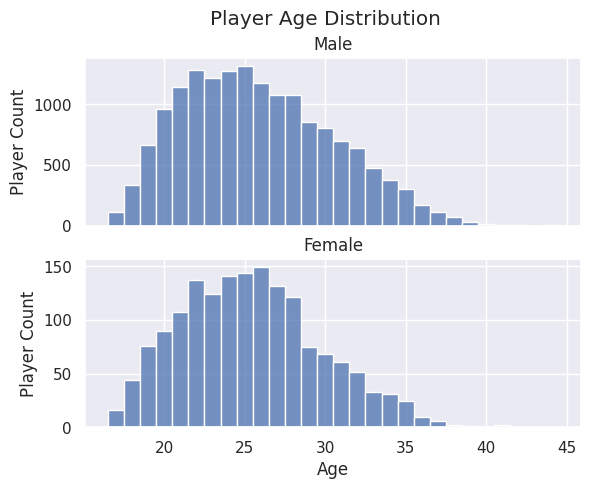

In [4]:
df_player_demographics = df_all_players[['Age','Nation','League','Team','Height(cm)','Weight(lbs)','GENDER']]

fig, axes = plt.subplots(2,1, sharex=True)

fig.suptitle('Player Age Distribution')

axes[0].set_title('Male')
axes[0].set_ylabel('Player Count')
sns.histplot(ax=axes[0],data=df_player_demographics[df_player_demographics['GENDER']=='M']['Age'],
             stat='count',
             discrete=True
            )

axes[1].set_title('Female')
axes[1].set_ylabel('Player Count')
sns.histplot(ax=axes[1],data=df_player_demographics[df_player_demographics['GENDER']=='F']['Age'],
             stat='count',
             discrete=True
            )

## Player Gender Distribution By Height

Text(0.5, 0.98, 'Height Distribution')

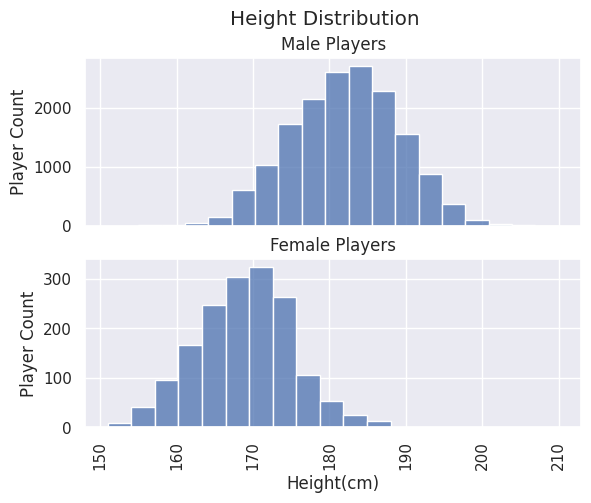

In [5]:
fig, axes = plt.subplots(2,1,sharex=True)

plt.xticks(rotation='vertical')
axes[0].set_ylabel('Player Count')
axes[0].set_title('Male Players')
axes[1].set_ylabel('Player Count')
axes[1].set_title('Female Players')
sns.histplot(ax=axes[0],
             data=df_all_players[df_all_players['GENDER']=='M']['Height(cm)'],
             stat='count', binwidth=3)

sns.histplot(ax=axes[1],data=df_all_players[df_all_players['GENDER']=='F']['Height(cm)'],
             stat='count', binwidth=3)

fig.suptitle("Height Distribution")


## Player Weight Distribution By Gender

<Axes: title={'center': 'Female Players'}, xlabel='Weight(lbs)', ylabel='Player Count'>

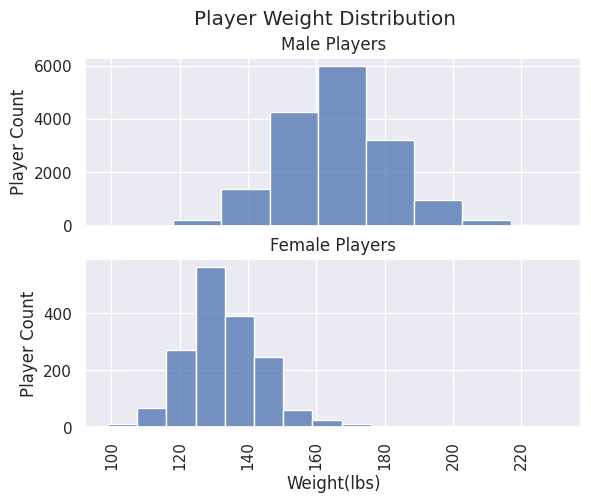

In [6]:
fig, axes = plt.subplots(2,1,sharex=True)

plt.xticks(rotation='vertical')
fig.suptitle("Player Weight Distribution")
axes[0].set_ylabel('Player Count')
axes[0].set_title('Male Players')
axes[1].set_ylabel('Player Count')
axes[1].set_title('Female Players')
sns.histplot(ax=axes[0],
             data=df_all_players[df_all_players['GENDER']=='M']['Weight(lbs)'],
             stat='count', bins=9)

sns.histplot(ax=axes[1],data=df_all_players[df_all_players['GENDER']=='F']['Weight(lbs)'],
             stat='count', bins=9)

## Player Nationalities

<Axes: title={'center': 'EAFC 26 - Top 20 Player Nationalities'}, xlabel='Nation', ylabel='count'>

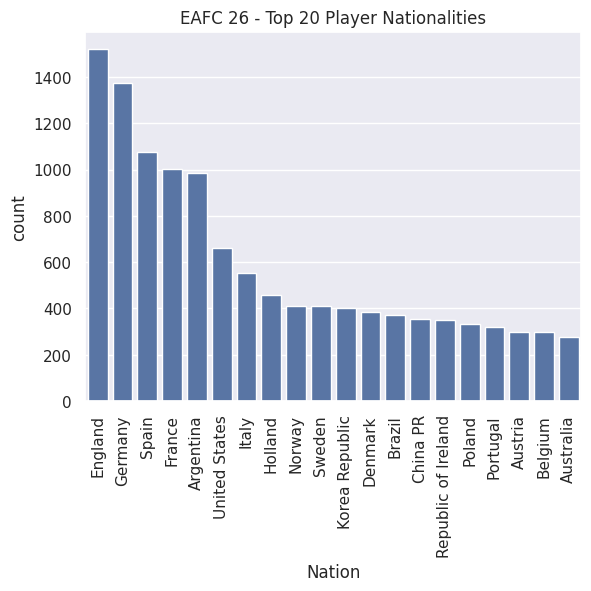

In [7]:
df_nationalities = df_all_players['Nation'].value_counts().reset_index()
df_nationalities['count'] = df_nationalities['count'].astype(int)

fig, ax = plt.subplots(1)
plt.xticks(rotation='vertical')
plt.title('EAFC 26 - Top 20 Player Nationalities')
sns.barplot(ax=ax,data=df_nationalities.iloc[:20], x='Nation', y='count')

## Players per League

<Axes: title={'center': 'EAFC 25 - Top 20 Leagues with the most Players'}, xlabel='League', ylabel='count'>

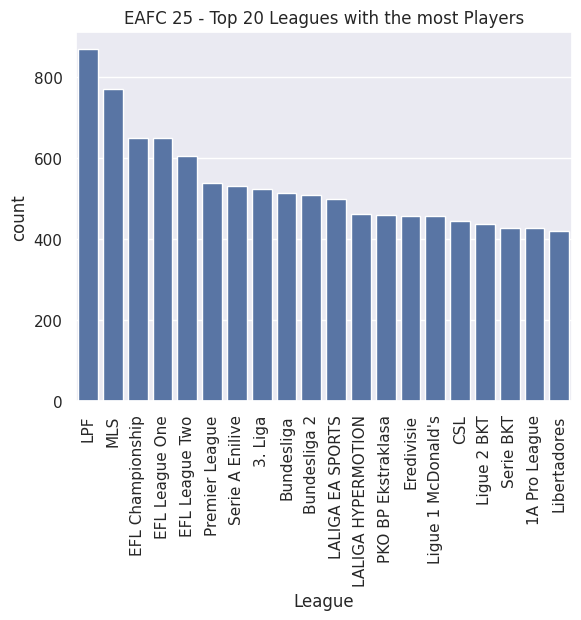

In [8]:
df_leagues = df_all_players['League'].value_counts().reset_index()
df_leagues['count'] = df_leagues['count'].astype(int)

fig, ax = plt.subplots(1)
plt.xticks(rotation='vertical')
plt.title('EAFC 25 - Top 20 Leagues with the most Players')
sns.barplot(ax=ax,data=df_leagues.iloc[:20], x='League', y='count')

# Player Statistics
## Main Attribute Distributions By Gender

<Axes: title={'center': 'Male vs. Female Player Comparison'}, xlabel='Attribute', ylabel='Value'>

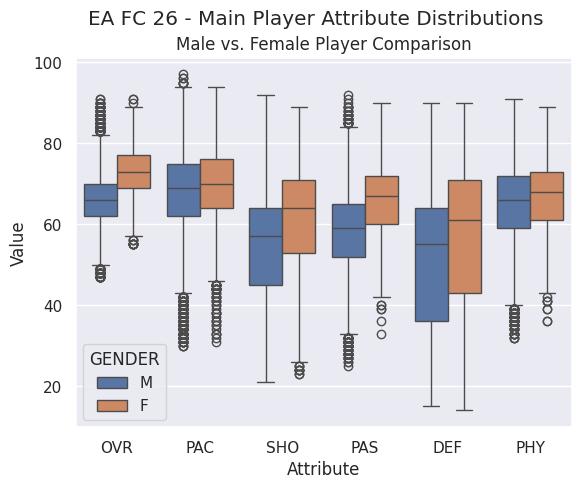

In [9]:
df_main_attributes = df_all_players[['Position','OVR','PAC','SHO','PAS','DEF','PHY','GENDER']].melt(id_vars=['Position','GENDER'],var_name='Attribute',value_name='Value')

plt.suptitle('EA FC 26 - Main Player Attribute Distributions')
plt.title('Male vs. Female Player Comparison')
sns.boxplot(data=df_main_attributes,x='Attribute',y='Value',hue='GENDER')

Each attribute has slightly different distributions. DEF shows the widest range of values with a slight skew to values velow 50. Pretty similar to SHO values with a slighly larger concentration around the mean value just below 60. PAS attributes display more outlier values both in the upper as in the lower ranges with a high concentration of players around the average value of 60. PAC, which groups acceleration and speed displays a higher amount of outliers in the low values.


## Average Attributes by Player Position
Comparing average player attributes for field positions (excluding GK) we see that midfielders show a more balanced attribute distribution of attacking, defending stats and pacing (which derives to speed and acceleration), they also have the greatest averages in passing (PAS) attributes which are key to their position. Defensive attributes (DEF) are top value for defenders as it should be expected while for forwards, the defensive average values are quite lower. However, forwards have the highest average values for shooting (SHO). Defenders also show the highets average values for physicality (PHY) due to the strenght required to challenge for the ball effectively both on ground and by air.

In [10]:
def generic_player_pos(pos):
    player_position_dict = {
        'Defender':['CB','LB','RB'],
        'Midfielder':['CAM','CM','CDM','LM','RM'],
        'Forward':['LW','RW','ST','SS'],
        'Goalkeeper':['GK']
    }
    for position in player_position_dict:
        if pos in player_position_dict[position]:
            return position
    return 'GK'
        

df_all_players['generic_position'] = df_all_players['Position'].apply(lambda x: generic_player_pos(x))

polar_df = df_all_players[['generic_position','OVR','PAC','SHO','PAS','DEF','PHY']]. \
  groupby('generic_position').mean().copy().reset_index()

polar_df=pd.melt(polar_df,id_vars='generic_position',value_vars=['OVR','PAC','SHO','PAS','DEF','PHY'],var_name='attribute',value_name='value')

figs=[None]*3

for gen_pos in ['Defender','Midfielder','Forward']:
    fig=px.line_polar(polar_df[polar_df['generic_position']==gen_pos],r='value',theta='attribute',line_close=True,title=gen_pos)
    fig.show()

## OVR Attribute Accross Player Age By Position In Field
For our generic field positioning of defenders, midfielders and forwards, we display the OVR parameter respect to player age.

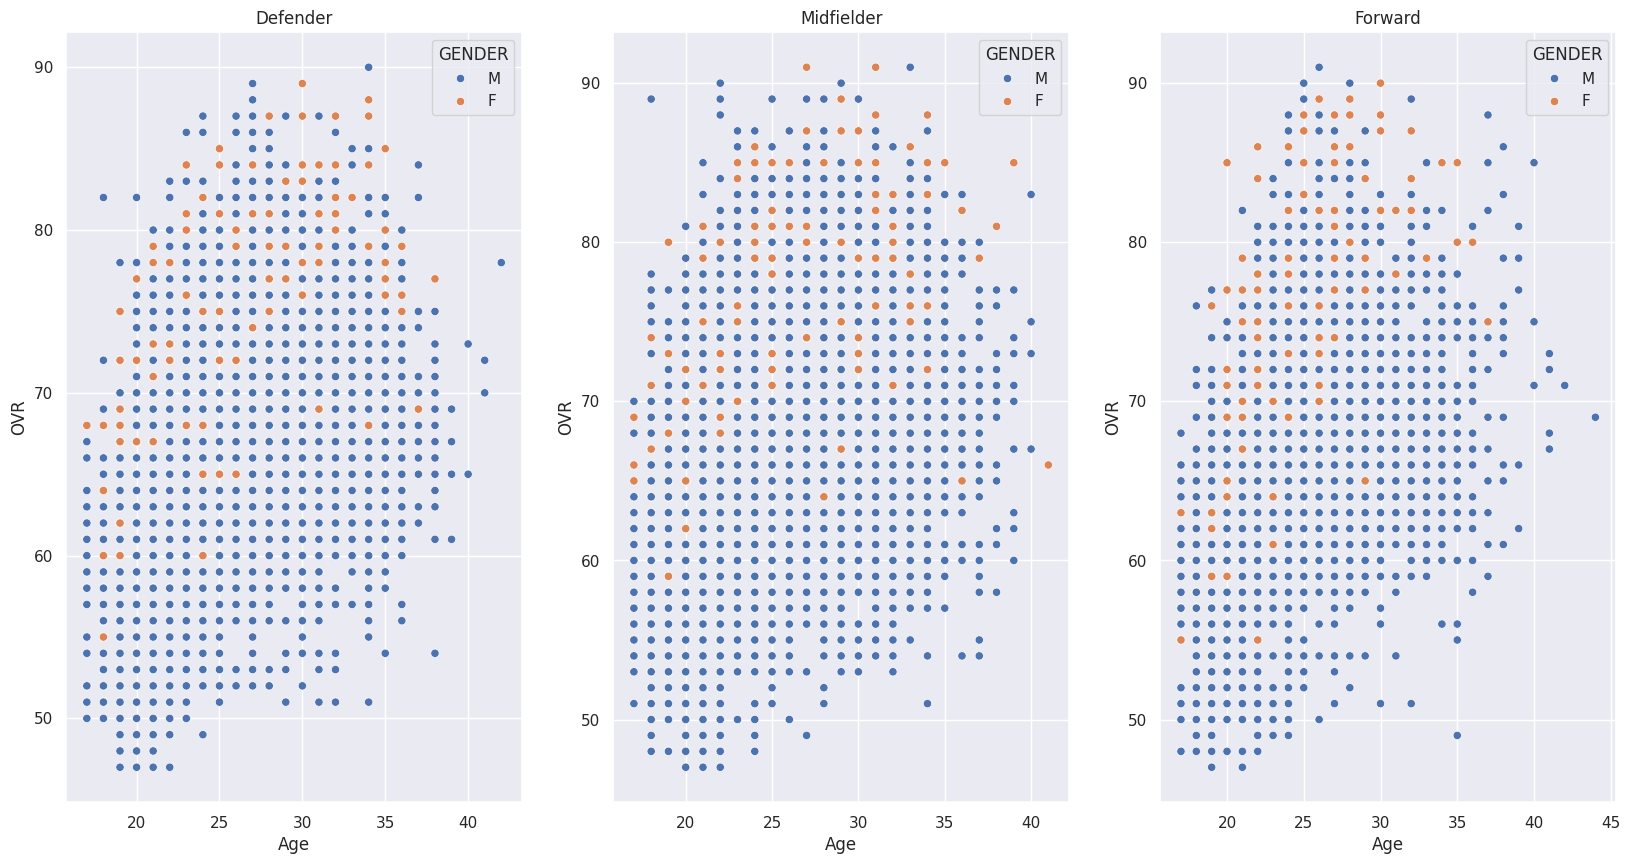

In [11]:
# OVR Atrribute related to player age
fig, ax = plt.subplots(ncols=3,figsize=(20,10))
for i, pos in enumerate(['Defender','Midfielder','Forward']):
    ax[i].set_title(pos)
    sns.scatterplot(df_all_players[df_all_players['generic_position']==pos], x='Age',y='OVR',hue='GENDER',ax=ax[i])

# 2026 World Cup Analytics

First we select players from the nations that will play in the world cup.
since we don't have specific lineups yet, we will rank players based on their position to try to build the best available squad with players from the EAFC database.

In [12]:
df_male_players = df_all_players[df_all_players['GENDER']=='M']

world_cup_nations = [
    "Canada", "Mexico", "United States",
    "Algeria", "Cape Verde", "Egypt", "Ghana", "Ivory Coast", "Morocco", "Senegal", "South Africa", "Tunisia",
    "Australia", "Iran", "Japan", "Jordan", "Qatar", "Saudi Arabia", "South Korea", "Uzbekistan",
    "Austria", "Belgium", "Croatia", "England", "France", "Germany", "Netherlands", "Norway", "Portugal", "Scotland", "Spain", "Switzerland",
    "Curaçao", "Haiti", "Panama",
    "New Zealand",
    "Argentina", "Brazil", "Colombia", "Ecuador", "Paraguay", "Uruguay"
]

df_world_cup_players = df_male_players[df_male_players['Nation'].apply(lambda x: x in world_cup_nations)]

In [13]:
df_world_cup_players['Nation'].value_counts()

Nation
England          1411
Germany          1122
Argentina         979
Spain             843
France            843
United States     400
Norway            385
Brazil            343
Portugal          302
Belgium           285
Saudi Arabia      270
Austria           266
Australia         257
Scotland          254
Switzerland       232
Uruguay           210
Colombia          177
Croatia           153
Paraguay          152
Morocco           121
Senegal           119
Ghana             116
Ecuador           107
Japan              99
Canada             80
Algeria            54
New Zealand        51
Tunisia            29
Mexico             27
South Africa       14
Haiti              12
Curaçao            12
Panama             11
Egypt               9
Iran                6
Uzbekistan          4
Jordan              2
Name: count, dtype: int64

## Building A Squad

National Teams can pick 26 players for the world cup. We have chosen this player distribution to conform one full squad:
* 4 Goalkeepers
* 8 Defenders
* 8 Midfielders
* 6 Forwards

In [14]:
# Ranking players based on their generic positions
proposed_wc_players = df_world_cup_players.iloc[:0,:].copy()

for nation in world_cup_nations:
    df_national_squad = df_world_cup_players[df_world_cup_players['Nation']==nation]
    for gen_pos in ['Goalkeeper','Defender','Midfielder','Forward']:
        players= df_national_squad[df_national_squad['generic_position']==gen_pos]
        players['rank']=players['OVR'].rank(ascending=False)

        if gen_pos == 'Goalkeeper':
            players=players.head(4)
        if gen_pos == 'Forward':
            players=players.head(6)
        else:
            players=players.head(8)
        
        proposed_wc_players=pd.concat([proposed_wc_players, players], ignore_index=True)

print(proposed_wc_players.shape)

proposed_wc_players['Nation'].value_counts()


(812, 63)


Nation
Canada           26
United States    26
Japan            26
Senegal          26
Ghana            26
Paraguay         26
Ecuador          26
Brazil           26
Australia        26
Belgium          26
Croatia          26
Austria          26
Saudi Arabia     26
England          26
France           26
Switzerland      26
Spain            26
Scotland         26
Portugal         26
Norway           26
Germany          26
Uruguay          26
New Zealand      26
Argentina        26
Colombia         26
Morocco          25
Mexico           24
Algeria          22
Tunisia          21
South Africa     14
Haiti            12
Curaçao          12
Panama           11
Egypt             9
Iran              6
Uzbekistan        4
Jordan            2
Name: count, dtype: int64

Due to available players in our datasets, we cannot infer squads for all countries but we'll take a look at some famous national teams for further data exploration.

## Sample Squad Creation: Building A Squad For Spain And Brazil

We have assigned generic player positions (Defenders, Midfielders, Forwards). We try to build a squad with the best players for each of this generic positions ranked by their OVR rating.

For this method we are ranking players among all nations qualified for the world cup in a single dataset and we are displyaing the proposed squad for Spain and Brazil by filterin on 'Nation'

In [15]:
proposed_wc_players[proposed_wc_players['Nation']=='Spain'][['Name','generic_position','Position','Alternative positions']].reset_index()

,index,Name,generic_position,Position,Alternative positions
0,543,David Raya,Goalkeeper,GK,NaN
1,544,Unai Simón,Goalkeeper,GK,NaN
2,545,De Gea,Goalkeeper,GK,NaN
3,546,Joan García,Goalkeeper,GK,NaN
4,547,Carvajal,Defender,RB,['RM']
5,548,Iñigo Martínez,Defender,CB,NaN
6,549,Marcos Llorente,Defender,RB,"['CM', 'RM']"
7,550,Marc Cucurella,Defender,LB,NaN
8,551,Vivian,Defender,CB,NaN
9,552,Balde,Defender,LB,['LM']


In [16]:
def print_national_squad1(df_players):
    # Creating a Matrix for the positions in the field
    lineup = {"Goalkeepers":[],
              "Defenders":{"Left":[],"Center":[],"Right":[]},
              "Midfielders":{"Left":[],"Center":[],"Right":[]},
              "Forwards":{"Left":[],"Center":[],"Right":[]}}
    
    for player in df_players.itertuples():
        if player[3]=='RB':
            lineup['Defenders']['Right'].append(player[1])
        elif player[3]=='CB':
            lineup['Defenders']['Center'].append(player[1])
        elif player[3]=='LB':
            lineup['Defenders']['Left'].append(player[1])
        elif player[3]=='RM':
            lineup['Midfielders']['Right'].append(player[1])
        elif player[3] in ['CM','CDM','CAM']:
            lineup['Midfielders']['Center'].append(player[1])
        elif player[3]=='LM':
            lineup['Midfielders']['Left'].append(player[1])
        elif player[3]=='RW':
            lineup['Forwards']['Right'].append(player[1])
        elif player[3]=='LW':
            lineup['Forwards']['Left'].append(player[1])
        elif player[3]=='ST':
            lineup['Forwards']['Center'].append(player[1])
        else:
            lineup['Goalkeepers'].append(player[1])
    
    for key, value in lineup.items():
        print(f"{key}, \n{value}")

# Another way of displaying the national sqad detailing field positions:
df_spain_squad1 = proposed_wc_players[proposed_wc_players['Nation']=='Spain'][['Name','generic_position','Position','Alternative positions']].copy()
df_brazil_squad1 = proposed_wc_players[proposed_wc_players['Nation']=='Brazil'][['Name','generic_position','Position','Alternative positions']].copy()

print("Spain National Team:\n============================")
print_national_squad1(df_spain_squad1)

print("\n\nBrazil National Team:\n===========================")
print_national_squad1(df_brazil_squad1)

Spain National Team:
Goalkeepers, 
['David Raya', 'Unai Simón', 'De Gea', 'Joan García']
Defenders, 
{'Left': ['Marc Cucurella', 'Balde'], 'Center': ['Iñigo Martínez', 'Vivian', 'Robin Le Normand'], 'Right': ['Carvajal', 'Marcos Llorente', 'Pedro Porro']}
Midfielders, 
{'Left': ['Nico Williams', 'Grimaldo'], 'Center': ['Rodri', 'Pedri', 'Fabián Ruiz', 'Dani Olmo', 'Sancet'], 'Right': ['Lamine Yamal']}
Forwards, 
{'Left': ['Ferran Torres'], 'Center': ['Ayoze', 'Oyarzabal', 'Gerard Moreno', 'Morata'], 'Right': ['Iago Aspas']}


Brazil National Team:
Goalkeepers, 
['Alisson', 'Ederson', 'Lucas Perri', 'Bento']
Defenders, 
{'Left': ['Carlos Augusto'], 'Center': ['Gabriel', 'Marquinhos', 'Bremer', 'Éder Militão', 'Murillo', 'Ibañez', 'Alexsandro'], 'Right': []}
Midfielders, 
{'Left': ['Raphinha'], 'Center': ['Bruno Guimarães', 'Matheus Cunha', 'Joelinton', 'Éderson', 'Malcom', 'Fabinho', 'Anderson Talisca'], 'Right': []}
Forwards, 
{'Left': ['Vini Jr.', 'Gabriel Martinelli', 'David Neres'],

We have come up with a suggested list of players by their OVR rating and position in the dataset.

However, it seems quite limiting if we use the "generic" positions we have defined, for example Lamine Yamal is the only RM in the resulting squad.

## Second Method: Building A Squad For England

We can explore a different logic to build a squad. We'll take England since it is the country with the most players in the dataset.

Through a Google Search, we know that Thomas Tuchel, England's head coach uses mainly these formations: (Quote from Gemini AI)

> 4-2-3-1: This is his most-used formation overall, often employed at Mainz, Dortmund, and Bayern Munich.
> 4-3-3: A primary formation during his time in Ligue 1 with PSG and also used with the England national team.

So the player requirements forthese two formations are :
*4-2-3-1:*
+ 4 Defenders
    - 1 LB
    - 2 CB
    - 1 RB
+ 2 Defensive Midfielders (CDM)
+ 3 Midfielders
  - 1 RM
  - 1 CM or CAM
  - 1 LM
+ 1 Striker (ST)

*4-3-3:*
+ 4 Defenders (Same as above)
+ 3 Midfielders (Same as above)
+ 3 Forwards
  - 1 LW
  - 1 ST
  - 1 RW

Since the goalkeeper, defenders and midfielders are the same for both formations we can have a single selection process for those positions. while adding CAM for the 4-2-3-1 formation and LW and RW for the 4-3-3 formation. One possible build could be the following:
* 4 Goalkeepers
* Defenders:
  - 2 LB
  - 4 CB
  - 2 RB
* Midfielders
  - 4 CDM
  - 1 LM
  - 2 CM or CAM
  - 1 RM
* Forwards
  - 2 LW
  - 2 ST
  - 2 RW

In [17]:
# Ranking players again, now based on their specific positions
proposed_wc_players = df_world_cup_players.iloc[:0,:].copy()

for nation in world_cup_nations:
    df_national_squad = df_world_cup_players[df_world_cup_players['Nation']==nation]
    for position in ['GK','LB','CB','RB','CDM','CM','CAM','LM','RW','ST','LW']:
        players= df_national_squad[df_national_squad['Position']==position]
        players['rank']=players['OVR'].rank(ascending=False)

        if position == 'GK':
            players=players.head(4)
        elif position in ['CB','CDM']:
            players=players.head(4)
        elif position in ['CM','CAM','LW','ST','RW','LB','RB']:
            players=players.head(2)
        elif position in ['LM','RM']:
            players=players.head(1)
        
        proposed_wc_players=pd.concat([proposed_wc_players, players], ignore_index=True)

proposed_wc_players[proposed_wc_players['Nation']=='England'][['Name','generic_position','Position','Alternative positions']].reset_index()

,index,Name,generic_position,Position,Alternative positions
0,370,Jordan Pickford,Goalkeeper,GK,NaN
1,371,Dean Henderson,Goalkeeper,GK,NaN
2,372,Nick Pope,Goalkeeper,GK,NaN
3,373,Aaron Ramsdale,Goalkeeper,GK,NaN
4,374,Lewis Hall,Defender,LB,NaN
5,375,Myles Lewis-Skelly,Defender,LB,['CM']
6,376,Ezri Konsa,Defender,CB,"['RB', 'RM']"
7,377,John Stones,Defender,CB,['RB']
8,378,Marc Guéhi,Defender,CB,NaN
9,379,Fikayo Tomori,Defender,CB,NaN
